# Controlled 3-state measure-valued 2BSDE: analytic benchmark

We test the reusable `two_bsde` package on

$$
\Theta\in\{-1,0,1\},
\qquad
dY_t=u_t\Theta\,dt+dW_t.
$$

The posterior satisfies

$$
d\pi_t^i
=
u_t\pi_t^i(\theta_i-\bar\theta_t)\,dI_t,
\qquad
\bar\theta_t=\sum_i\pi_t^i\theta_i.
$$

Thus the control genuinely changes the posterior diffusion.

Define

$$
b_i(\pi)=\pi_i(\theta_i-\bar\theta),
\qquad
S(\pi)=\sum_i b_i(\pi)^2,
$$

and choose

$$
k(\pi,u)
=
\frac12 u^2 S(\pi)
+
\frac{\lambda}{2}(u-1)^2,
$$

with terminal cost

$$
g(\pi)
=
\frac12(1-\|\pi\|^2).
$$

For

$$
V(t,y,\pi)=\frac12(1-\|\pi\|^2),
$$

we have $D^2_{\pi\pi}V=-I$, so the KS second-order term is

$$
-\frac12u^2S(\pi),
$$

which cancels the first term in the running cost. Hence the HJB reduces to

$$
\min_{u\in[-1,1]}
\frac{\lambda}{2}(u-1)^2=0.
$$

Therefore the exact solution is

$$
\boxed{
V(t,y,\pi)=\frac12(1-\|\pi\|^2),
\qquad
u^*(t,y,\pi)\equiv1.
}
$$

This gives an analytic benchmark for the value, gradient, Hessian, and optimal control while retaining a genuinely controlled KS measure process.

In [49]:
from pathlib import Path
import math
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from two_bsde.config import ModelConfig, HamiltonianConfig, TrainingConfig
from two_bsde.problem import BayesianControlProblem
from two_bsde.geometry import make_simplex_tangent_basis, SimplexGeometry
from two_bsde.hamiltonian import HamiltonianOptimizer
from two_bsde.model import GeometricClassicalFixedAux2BSDE
from two_bsde.dynamics import split_state, posterior_mean_sensor_and_diffusion
from two_bsde.training import train
from two_bsde.evaluation import evaluate

DTYPE = torch.float64
DEVICE = torch.device("cpu")

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
config = ModelConfig(
    horizon=1.0,
    hidden_dim=1,
    observation_dim=1,
    control_dim=1,
    num_hidden_states=3,
    num_time_steps=20,
    network_width=64,
    network_depth=5,
    value_initial_guess=0.30,
    gamma_initial_scale=0.05,
)

ham_config = HamiltonianConfig(
    num_starts=12,
    num_steps=30,
    learning_rate=5e-2,
)

training_config = TrainingConfig(
    epochs=500,
    batch_size=64,
    learning_rate=3e-3,
    gradient_clip=10.0,
    value_loss_weight=1.0,
    gradient_loss_weight=1.0,
)

basis = make_simplex_tangent_basis(
    config.num_hidden_states,
    dtype=DTYPE,
    device=DEVICE,
)

geometry = SimplexGeometry(
    observation_dim=config.observation_dim,
    basis=basis,
)

print("state_dim =", config.state_dim)
print("tangent_dim =", config.tangent_dim)

state_dim = 4
tangent_dim = 2


## Concrete problem

In [51]:
class ControlledThreeStateProblem(BayesianControlProblem):
    def __init__(self, config, lam=1.0):
        super().__init__(config)
        self.lam = float(lam)

        self.theta = torch.tensor([-1.0, 0.0, 1.0], dtype=DTYPE, device=DEVICE)
        self.x_support = self.theta[:, None].clone()

        self.initial_observation = torch.tensor([0.0], dtype=DTYPE, device=DEVICE)
        self.initial_posterior = torch.tensor([0.25, 0.50, 0.25], dtype=DTYPE, device=DEVICE)

        self.control_low = torch.tensor([-1.0], dtype=DTYPE, device=DEVICE)
        self.control_high = torch.tensor([1.0], dtype=DTYPE, device=DEVICE)

        # regarded as hyperparameter, can be tuned to improve performance
        # it is deterministic, can be time-dependent
        self.auxiliary_control_path = torch.zeros(
            config.num_time_steps,
            config.control_dim,
            dtype=DTYPE,
            device=DEVICE,
        )

        self.validate(config)

    def sensor(self, control, observation):
        lead_shape = control.shape[:-1]
        theta = self.theta.reshape(
            *([1] * len(lead_shape)),
            self.config.num_hidden_states,
            1,
        )
        return control.unsqueeze(-2) * theta

    def running_cost(self, state, control):
        p = state[..., self.config.observation_dim:]
        theta_bar = (p * self.theta).sum(dim=-1,keepdim=True)
        b = p * (self.theta - theta_bar)
        u = control[..., 0]

        cancellation_term = (
            0.5 * u.square() * b.square().sum(dim=-1)
        )

        force_u_to_one = (
            0.5 * self.lam * (u - 1.0).square()
        )

        return cancellation_term + force_u_to_one

    def terminal_cost(self, state):
        _, p = split_state(state, self.config)
        return 0.5 * (1.0 - p.square().sum(dim=-1))


problem = ControlledThreeStateProblem(config)
S0 = torch.cat(
    (problem.initial_observation, problem.initial_posterior)
)

print("S0 =", S0)
print("theta =", problem.theta)
print("auxiliary control =", problem.auxiliary_control_path.squeeze(-1))

S0 = tensor([0.0000, 0.2500, 0.5000, 0.2500], dtype=torch.float64)
theta = tensor([-1.,  0.,  1.], dtype=torch.float64)
auxiliary control = tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.], dtype=torch.float64)


## Analytic solution

In [52]:
def exact_value(state):
    p = state[..., 1:]
    return 0.5 * (1.0 - p.square().sum(dim=-1))


def exact_gradient(state):
    ambient = torch.zeros_like(state)
    ambient[..., 1:] = -state[..., 1:]
    return geometry.project_gradient(ambient)


def exact_hessian(state):
    shape = state.shape[:-1] + (
        config.state_dim,
        config.state_dim,
    )
    gamma = torch.zeros(
        shape,
        dtype=state.dtype,
        device=state.device,
    )
    gamma[..., 1:, 1:] = -geometry.projector
    return gamma


def exact_control(state):
    return torch.ones(
        *state.shape[:-1],
        1,
        dtype=state.dtype,
        device=state.device,
    )


V0_exact = exact_value(S0)
Z0_exact = exact_gradient(S0)
Gamma0_exact = exact_hessian(S0)
u0_exact = exact_control(S0)

print("exact V0 =", V0_exact.item())
print("exact Z0 =", Z0_exact)
print("exact Gamma0 =\n", Gamma0_exact)
print("exact u0* =", u0_exact)

exact V0 = 0.3125
exact Z0 = tensor([ 0.0000,  0.0833, -0.1667,  0.0833], dtype=torch.float64)
exact Gamma0 =
 tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000, -0.6667,  0.3333,  0.3333],
        [ 0.0000,  0.3333, -0.6667,  0.3333],
        [ 0.0000,  0.3333,  0.3333, -0.6667]], dtype=torch.float64)
exact u0* = tensor([1.], dtype=torch.float64)


## Verify the analytic HJB

In [53]:
def analytic_hjb_expression(state, control):
    _, B = posterior_mean_sensor_and_diffusion(
        state,
        control,
        problem=problem,
        config=config,
        geometry=geometry,
    )

    running = problem.running_cost(
        state,
        control,
    )

    second_order = (
        -0.5
        * B.square().sum(dim=(-2, -1))
    )

    return running + second_order


test_states = torch.tensor(
    [
        [0.0, 0.20, 0.50, 0.30],
        [0.4, 0.70, 0.20, 0.10],
        [-0.6, 0.05, 0.20, 0.75],
    ],
    dtype=DTYPE,
)

u_exact = exact_control(test_states)
hjb_at_exact = analytic_hjb_expression(
    test_states,
    u_exact,
)

print("HJB at u=1:", hjb_at_exact)
assert torch.allclose(
    hjb_at_exact,
    torch.zeros_like(hjb_at_exact),
    atol=1e-12,
)

for u_value in [-1.0, -0.5, 0.0, 0.5]:
    u = torch.full((len(test_states), config.control_dim), u_value, dtype=DTYPE)
    value = analytic_hjb_expression(test_states, u)
    print(f"u={u_value:+.1f}, HJB terms={value.numpy()}")
    assert torch.all(value > 0)

print("analytic HJB check: PASSED")

HJB at u=1: tensor([4.1633e-17, 4.1633e-17, 1.3878e-17], dtype=torch.float64)
u=-1.0, HJB terms=[2. 2. 2.]
u=-0.5, HJB terms=[1.125 1.125 1.125]
u=+0.0, HJB terms=[0.5 0.5 0.5]
u=+0.5, HJB terms=[0.125 0.125 0.125]
analytic HJB check: PASSED


## Build the 2BSDE model

In [54]:
hamiltonian_optimizer = HamiltonianOptimizer(
    problem=problem,
    model_config=config,
    optimizer_config=ham_config,
    geometry=geometry,
)

model = GeometricClassicalFixedAux2BSDE(
    problem=problem,
    config=config,
    geometry=geometry,
    hamiltonian_optimizer=hamiltonian_optimizer,
).to(device=DEVICE, dtype=DTYPE)

print(model)

GeometricClassicalFixedAux2BSDE(
  (blocks): ModuleList(
    (0-48): 49 x GeometricParallelBlock(
      (a_net): Sequential(
        (0): Linear(in_features=4, out_features=64, bias=True)
        (1): Tanh()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): Tanh()
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): Tanh()
        (6): Linear(in_features=64, out_features=3, bias=True)
      )
      (gamma_net): Sequential(
        (0): Linear(in_features=4, out_features=64, bias=True)
        (1): Tanh()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): Tanh()
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): Tanh()
        (6): Linear(in_features=64, out_features=6, bias=True)
      )
    )
  )
)


## Train the 2BSDE

In [55]:
history = train(
    model,
    model_config=config,
    training_config=training_config,
    verbose=True,
)

epoch=   1  loss=2.929e-02  value=1.191e-02  grad=1.738e-02  V0=0.303000  corr=0.00e+00
epoch=  50  loss=9.955e-04  value=3.277e-04  grad=6.678e-04  V0=0.340340  corr=0.00e+00
epoch= 100  loss=4.914e-05  value=2.545e-05  grad=2.369e-05  V0=0.340675  corr=0.00e+00
epoch= 150  loss=1.539e-05  value=6.199e-06  grad=9.190e-06  V0=0.341330  corr=0.00e+00
epoch= 200  loss=1.012e-05  value=3.508e-06  grad=6.612e-06  V0=0.341709  corr=0.00e+00
epoch= 250  loss=7.285e-06  value=2.054e-06  grad=5.231e-06  V0=0.342317  corr=0.00e+00
epoch= 300  loss=6.421e-06  value=2.286e-06  grad=4.135e-06  V0=0.342530  corr=0.00e+00
epoch= 350  loss=8.872e-06  value=4.398e-06  grad=4.474e-06  V0=0.342830  corr=0.00e+00
epoch= 400  loss=5.934e-06  value=1.586e-06  grad=4.348e-06  V0=0.343226  corr=0.00e+00
epoch= 450  loss=7.698e-06  value=3.992e-06  grad=3.706e-06  V0=0.343165  corr=0.00e+00
epoch= 500  loss=9.142e-06  value=2.956e-06  grad=6.186e-06  V0=0.343419  corr=0.00e+00


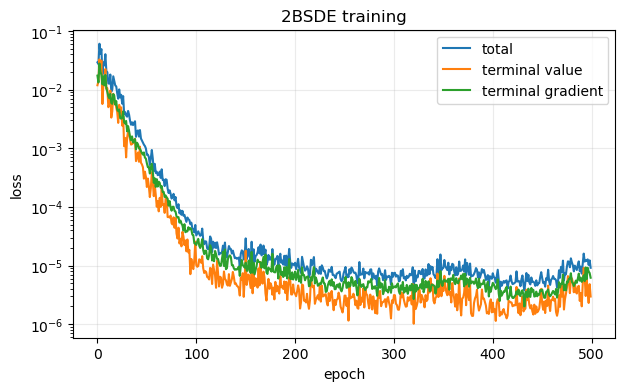

In [56]:
plt.figure(figsize=(7, 4))
plt.semilogy(history.total_loss, label="total")
plt.semilogy(history.value_loss, label="terminal value")
plt.semilogy(history.gradient_loss, label="terminal gradient")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("2BSDE training")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Compare learned initial quantities with the analytic solution

In [62]:
with torch.no_grad():
    V0_learned = model.initial_value.detach()
    Z0_learned = geometry.vector_from_raw(
        model.initial_gradient_raw.detach()
    )
    A0_learned = geometry.vector_from_raw(
        model.initial_drift_gradient_raw.detach()
    )
    Gamma0_learned = geometry.gamma_from_raw(
        model.initial_gamma_raw.detach()
    )

print("VALUE")
print(" learned:", V0_learned.item())
print(" exact:  ", V0_exact.item())
print(" abs err:", abs(V0_learned.item() - V0_exact.item()))

print("\nGRADIENT")
print(" learned:", Z0_learned)
print(" exact:  ", Z0_exact)
print(
    " L2 err:",
    torch.linalg.vector_norm(Z0_learned - Z0_exact).item(),
)

print("\nDRIFT OF GRADIENT A")
print(" learned:", A0_learned)
print(" exact:   zero")

print("\nHESSIAN")
print(" learned:\n", Gamma0_learned)
print(" exact:\n", Gamma0_exact)
print(
    " Frobenius err:",
    torch.linalg.matrix_norm(
        Gamma0_learned - Gamma0_exact
    ).item(),
)

VALUE
 learned: 0.34341871197929136
 exact:   0.3125
 abs err: 0.030918711979291358

GRADIENT
 learned: tensor([-0.0004,  0.0051, -0.0092,  0.0041], dtype=torch.float64)
 exact:   tensor([ 0.0000,  0.0833, -0.1667,  0.0833], dtype=torch.float64)
 L2 err: 0.19283813522429877

DRIFT OF GRADIENT A
 learned: tensor([-4.2671e-07,  5.1483e-03, -9.2164e-03,  4.0682e-03],
       dtype=torch.float64)
 exact:   zero

HESSIAN
 learned:
 tensor([[-0.0104,  0.0570, -0.0209, -0.0361],
        [ 0.0570, -0.0086,  0.0127, -0.0042],
        [-0.0209,  0.0127, -0.0240,  0.0113],
        [-0.0361, -0.0042,  0.0113, -0.0071]], dtype=torch.float64)
 exact:
 tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000, -0.6667,  0.3333,  0.3333],
        [ 0.0000,  0.3333, -0.6667,  0.3333],
        [ 0.0000,  0.3333,  0.3333, -0.6667]], dtype=torch.float64)
 Frobenius err: 1.3900005051308342


## Test the inner Hamiltonian optimizer with the analytic control $u^*=1$

In [58]:
with torch.no_grad():
    state_batch = torch.tensor(
        [
            [0.0, 0.25, 0.50, 0.25],
            [0.2, 0.10, 0.20, 0.70],
            [-0.3, 0.65, 0.25, 0.10],
        ],
        dtype=DTYPE,
    )

    z_batch = torch.stack(
        [exact_gradient(s) for s in state_batch]
    )
    gamma_batch = torch.stack(
        [exact_hessian(s) for s in state_batch]
    )

    _, u_from_exact_derivatives = hamiltonian_optimizer.minimise(
        state_batch,
        z_batch,
        gamma_batch,
    )

print("using exact derivatives:")
print(" numerical u* =", u_from_exact_derivatives[:, 0])
print(" analytic  u* =", torch.ones(len(state_batch), dtype=DTYPE))
print(
    " max abs error =",
    (u_from_exact_derivatives[:, 0] - 1.0).abs().max().item(),
)

using exact derivatives:
 numerical u* = tensor([1., 1., 1.], dtype=torch.float64)
 analytic  u* = tensor([1., 1., 1.], dtype=torch.float64)
 max abs error = 0.0


## Fresh-path 2BSDE evaluation

In [59]:
result = evaluate(
    model,
    num_paths=500,
)

paths = result.paths

u_star_path = paths["u_star_path"][..., 0]
mean_u_by_time = u_star_path.mean(dim=0)
mae_u_by_time = (u_star_path - 1.0).abs().mean(dim=0)

print("evaluation diagnostics:", result.diagnostics)
print("mean learned u* over all paths/times =", u_star_path.mean().item())
print("mean absolute control error =", (u_star_path - 1.0).abs().mean().item())

evaluation diagnostics: {'posterior_correction_rate': 0.0, 'mean_u_star': 0.9230163333333333}
mean learned u* over all paths/times = 0.9230163333333333
mean absolute control error = 0.07698366666666667


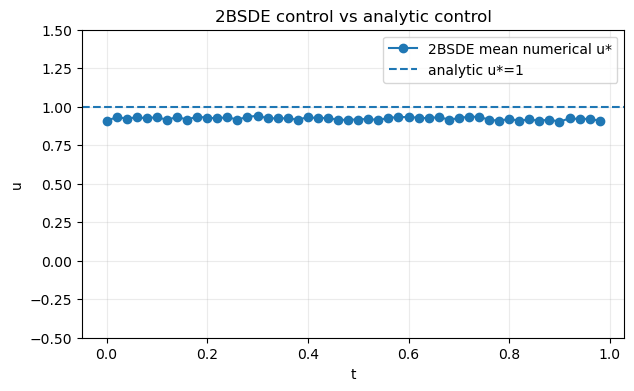

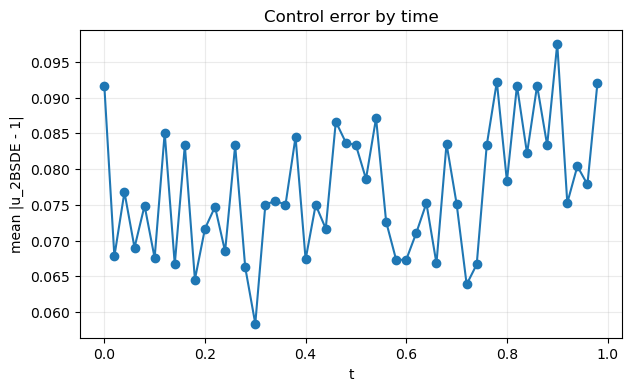

In [63]:
time_grid = torch.arange(
    config.num_time_steps,
    dtype=DTYPE,
) * config.dt

plt.figure(figsize=(7, 4))
plt.plot(
    time_grid.numpy(),
    mean_u_by_time.numpy(),
    marker="o",
    label="2BSDE mean numerical u*",
)
plt.axhline(
    1.0,
    linestyle="--",
    label="analytic u*=1",
)
plt.xlabel("t")
plt.ylabel("u")
plt.ylim(-0.5, 1.5)
plt.title("2BSDE control vs analytic control")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    time_grid.numpy(),
    mae_u_by_time.numpy(),
    marker="o",
)
plt.xlabel("t")
plt.ylabel("mean |u_2BSDE - 1|")
plt.title("Control error by time")
plt.grid(alpha=0.25)
plt.show()

## Analytic posterior path under $u^*\equiv1$

With the exact control,

$$
dY_t=\Theta\,dt+dW_t.
$$

The posterior has the explicit finite-state Bayes formula

$$
\pi_t^i
=
\frac{
\pi_0^i
\exp\left(\theta_iY_t-\frac12\theta_i^2t\right)
}{
\sum_j
\pi_0^j
\exp\left(\theta_jY_t-\frac12\theta_j^2t\right)
}.
$$

This provides a separate reference for checking the KS component.

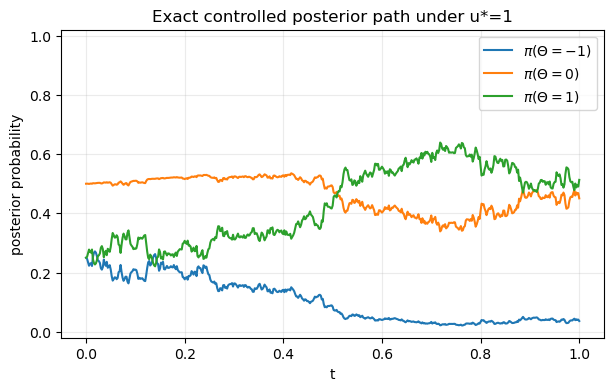

In [61]:
def exact_posterior_u_one(t, y, prior, theta):
    t = torch.as_tensor(t, dtype=DTYPE)
    y = torch.as_tensor(y, dtype=DTYPE)

    log_w = (
        torch.log(prior)
        + theta * y[..., None]
        - 0.5 * theta.square() * t[..., None]
    )
    log_w = log_w - log_w.max(dim=-1, keepdim=True).values
    w = torch.exp(log_w)
    return w / w.sum(dim=-1, keepdim=True)


steps = 500
dt = config.horizon / steps
times = torch.linspace(0, config.horizon, steps + 1, dtype=DTYPE)

true_theta = torch.tensor(1.0, dtype=DTYPE)
dW = math.sqrt(dt) * torch.randn(steps, dtype=DTYPE)
W = torch.cat([torch.zeros(1, dtype=DTYPE), torch.cumsum(dW, dim=0)])
Y = true_theta * times + W

posterior_exact = exact_posterior_u_one(
    times,
    Y,
    problem.initial_posterior,
    problem.theta,
)

plt.figure(figsize=(7, 4))
for i, theta_i in enumerate(problem.theta.tolist()):
    plt.plot(
        times.numpy(),
        posterior_exact[:, i].numpy(),
        label=fr"$\pi(\Theta={theta_i:g})$",
    )
plt.xlabel("t")
plt.ylabel("posterior probability")
plt.title("Exact controlled posterior path under u*=1")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Main benchmark targets

The 2BSDE result should approach

$$
V_0
=
\frac12\left(1-\|\pi_0\|^2\right),
$$

$$
D_\pi^{\mathrm{tan}}V_0
=
-P_{\mathrm{tan}}\pi_0,
$$

$$
D^2_{\pi\pi,\mathrm{tan}}V_0
=
-P_{\mathrm{tan}},
$$

and, most visibly,

$$
\boxed{u^*\equiv1.}
$$

The reference/auxiliary control is also set to one, so the simulated posterior used during training genuinely evolves rather than being frozen.